# 📊 Unemployment in India — Professional Data Analysis & Multi-Model Prediction
---
| | |
|---|---|
| **Author** | Data Science Lab |
| **Dataset 1** | `Unemployment_in_India.csv` — 768 records · 28 states/UTs · Rural & Urban breakdown |
| **Dataset 2** | `Unemployment_Rate_upto_11_2020.csv` — 267 records · Jan–Nov 2020 · with geo-coordinates |
| **Period** | May 2019 – Nov 2020 (includes COVID-19 lockdown shock) |
| **Target** | `Estimated Unemployment Rate (%)` |
| **Models** | 10 algorithms — Linear → Tree-based → Gradient Boosting → XGBoost → LightGBM |

---
## Table of Contents
1. [Library Imports & Global Settings](#1)
2. [Data Loading & Cleaning](#2)
3. [Dataset Overview & Missing Value Analysis](#3)
4. [National Unemployment Trend Over Time](#4)
5. [Rural vs Urban Unemployment Over Time](#5)
6. [COVID-19 Impact Analysis](#6)
7. [State-wise Unemployment — Bar & Box Plots](#7)
8. [Zone-wise Distribution (Dataset 2)](#8)
9. [Scatter Analysis — Feature Relationships](#9)
10. [Distribution Analysis — Histograms & KDE](#10)
11. [Violin & Strip Overlay Plots](#11)
12. [Pair Plot — All Feature Combinations](#12)
13. [Correlation Heatmap & Region×Month Heatmap](#13)
14. [Feature Engineering](#14)
15. [Train / Test Split & Scaling](#15)
16. [Training 10 Models — Cross-Validated Comparison](#16)
17. [Model Performance Visualisation](#17)
18. [Best Model — Hyperparameter Tuning (GridSearchCV)](#18)
19. [Final Model Evaluation on Test Set](#19)
20. [Actual vs Predicted & Residual Analysis](#20)
21. [Feature Importance & SHAP-style Analysis](#21)
22. [Learning Curves](#22)
23. [Prediction Error Distribution](#23)
24. [Comprehensive Model Summary Table](#24)
25. [Conclusions](#25)

---
## 1. Library Imports & Global Settings <a id='1'></a>

All libraries are imported in one place. We configure a consistent, publication-quality visual theme across all plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from pathlib import Path

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = 'Set2'
ACCENT  = '#2563EB'
SEED    = 42


---
## 2. Data Loading & Cleaning <a id='2'></a>

Both datasets are loaded, column names are normalised (whitespace stripped), the `Date` column is parsed to `datetime`, and columns are renamed to clean, snake_case identifiers. A Frequency column inconsistency (`'Monthly'` vs `' Monthly'`) is also fixed.

In [2]:
BASE_DIR = Path.cwd().parent

file_path  = BASE_DIR / 'Datasets' / 'Unemployment in India.csv'
file_path2 = BASE_DIR / 'Datasets' / 'Unemployment_Rate_upto_11_2020.csv'

df  = pd.read_csv(file_path)
df2 = pd.read_csv(file_path2)

for frame in [df, df2]:
    frame.columns = frame.columns.str.strip()

RENAME = {
    'Estimated Unemployment Rate (%)':      'Unemployment_Rate',
    'Estimated Employed':                   'Employed',
    'Estimated Labour Participation Rate (%)': 'LPR',
}
df.rename(columns=RENAME, inplace=True)
df2.rename(columns={**RENAME, 'Region.1': 'Zone'}, inplace=True)

df['Date']  = pd.to_datetime(df['Date'].str.strip(),  dayfirst=True, errors='coerce')
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), dayfirst=True, errors='coerce')

df['Frequency']  = df['Frequency'].str.strip()
df2['Frequency'] = df2['Frequency'].str.strip()

df['Month']  = df['Date'].dt.month
df['Year']   = df['Date'].dt.year
df['Quarter']= df['Date'].dt.quarter
df['YM']     = df['Date'].dt.to_period('M').astype(str)

print(f'Dataset 1 shape  : {df.shape}')
print(f'Dataset 2 shape  : {df2.shape}')
print(f'Date range (df)  : {df["Date"].min().date()}  →  {df["Date"].max().date()}')
print(f'Date range (df2) : {df2["Date"].min().date()} →  {df2["Date"].max().date()}')
df.head(10)

Dataset 1 shape  : (768, 11)
Dataset 2 shape  : (267, 9)
Date range (df)  : 2019-05-31  →  2020-06-30
Date range (df2) : 2020-01-31 →  2020-10-31


,Region,Date,Frequency,Unemployment_Rate,Employed,LPR,Area,Month,Year,Quarter,YM
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5.0,2019.0,2.0,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6.0,2019.0,2.0,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7.0,2019.0,3.0,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8.0,2019.0,3.0,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9.0,2019.0,3.0,2019-09
5,Andhra Pradesh,2019-10-31,Monthly,3.52,12017412.0,43.01,Rural,10.0,2019.0,4.0,2019-10
6,Andhra Pradesh,2019-11-30,Monthly,4.12,11397681.0,41.00,Rural,11.0,2019.0,4.0,2019-11
7,Andhra Pradesh,2019-12-31,Monthly,4.38,12528395.0,45.14,Rural,12.0,2019.0,4.0,2019-12
8,Andhra Pradesh,2020-01-31,Monthly,4.84,12016676.0,43.46,Rural,1.0,2020.0,1.0,2020-01
9,Andhra Pradesh,2020-02-29,Monthly,5.91,11723617.0,42.83,Rural,2.0,2020.0,1.0,2020-02


---
## 3. Dataset Overview & Missing Value Analysis <a id='3'></a>

We inspect data types, check for missing values, and review the statistical summary of all numeric variables.

In [3]:
print('── Column Data Types ──────────────────────────────')
print(df.dtypes)
print()
print('── Area Distribution ──────────────────────────────')
print(df['Area'].value_counts())
print()
print('── Unique States / UTs ────────────────────────────')
print(sorted([r for r in df['Region'].unique() if isinstance(r, str)]))

── Column Data Types ──────────────────────────────
Region                          str
Date                 datetime64[us]
Frequency                       str
Unemployment_Rate           float64
Employed                    float64
LPR                         float64
Area                            str
Month                       float64
Year                        float64
Quarter                     float64
YM                              str
dtype: object

── Area Distribution ──────────────────────────────
Area
Urban    381
Rural    359
Name: count, dtype: int64

── Unique States / UTs ────────────────────────────
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


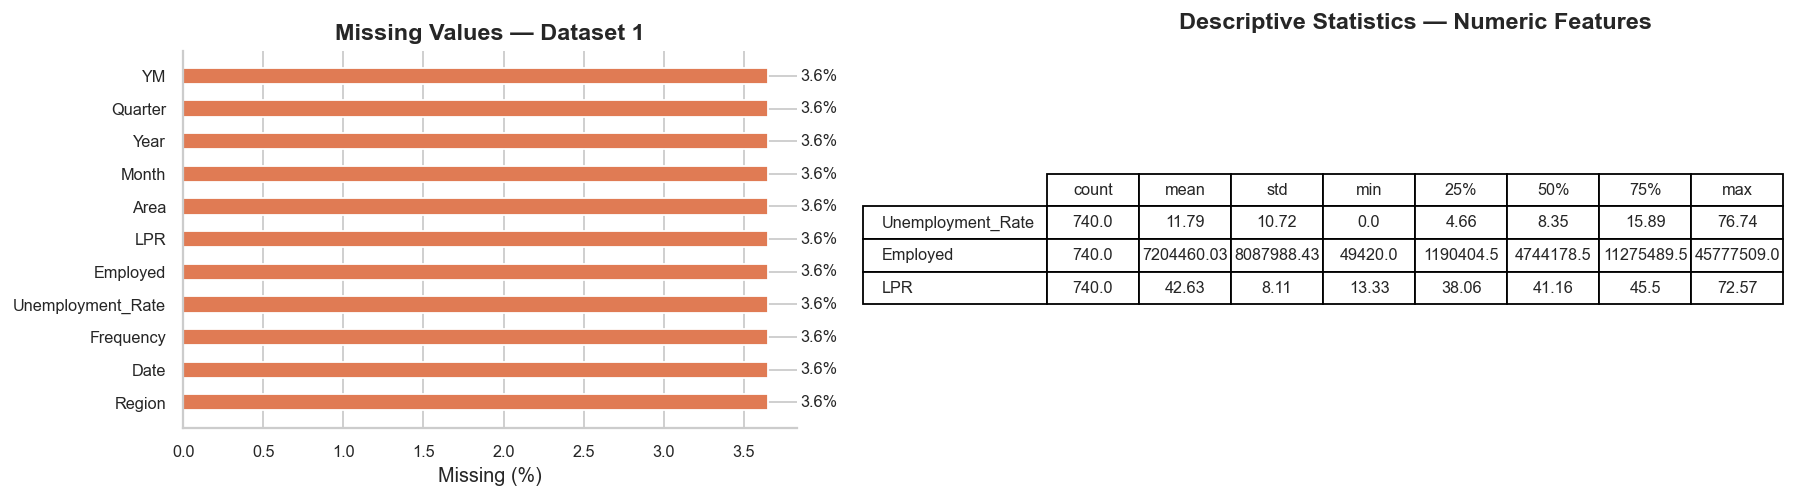

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]

bars = axes[0].barh(miss_df.index, miss_df['Missing %'],
                    color='#E07B54', edgecolor='white', height=0.5)
for bar, val in zip(bars, miss_df['Missing %']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_title('Missing Values — Dataset 1', fontweight='bold')
axes[0].set_xlabel('Missing (%)')

desc = df[['Unemployment_Rate','Employed','LPR']].describe().T
axes[1].axis('off')
tbl = axes[1].table(
    cellText=desc.round(2).values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
axes[1].set_title('Descriptive Statistics — Numeric Features', fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

In [5]:
df[['Unemployment_Rate', 'Employed', 'LPR']].describe().round(2)

,Unemployment_Rate,Employed,LPR
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


**Key observations:**
- `Area` has **28 missing rows** (3.6 %) — these are national/aggregate rows without a Rural/Urban label; we retain them for time-series analysis but drop them for Area-stratified plots.
- `Unemployment_Rate` ranges from **0 % to 76.74 %** — the extreme upper values correspond to the April–May 2020 COVID lockdown.
- Median unemployment (8.35 %) is well below the mean (11.79 %), confirming a **right-skewed distribution** driven by the lockdown spike.

---
## 4. National Unemployment Trend Over Time <a id='4'></a>

The monthly national average unemployment rate is plotted with a shaded confidence band and annotated pandemic event markers.

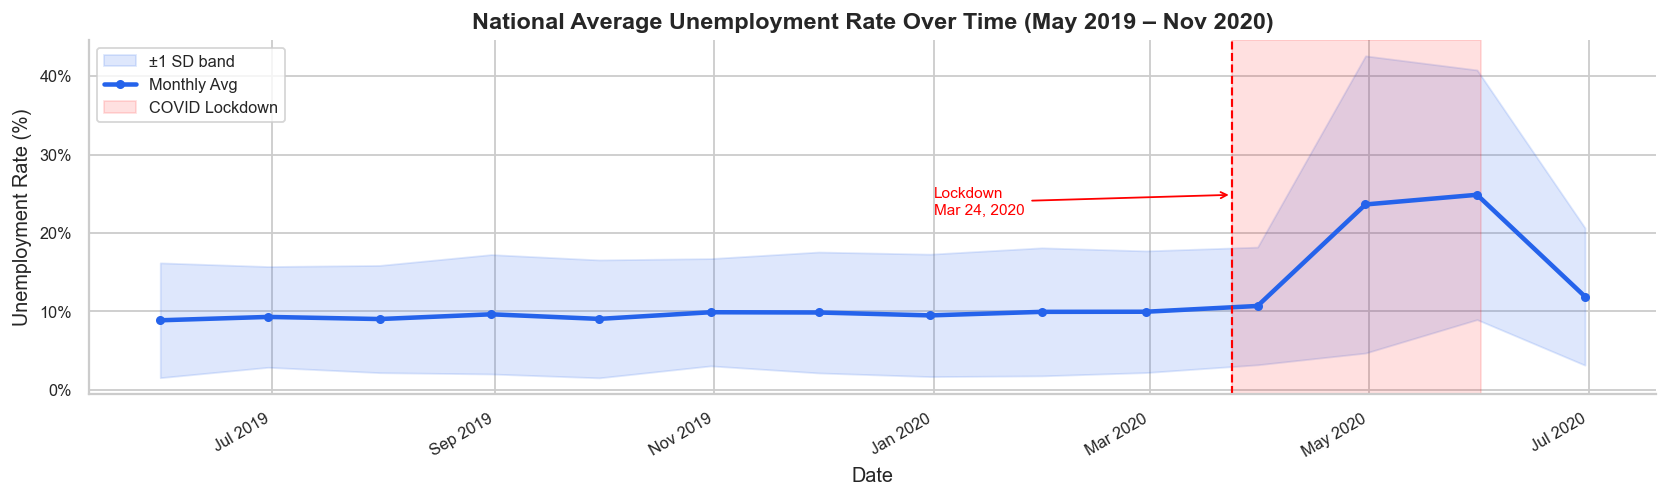

In [6]:
national = df.groupby('Date')['Unemployment_Rate'].agg(['mean','std']).reset_index()
national.columns = ['Date','Mean','Std']

fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(national['Date'],
                national['Mean'] - national['Std'],
                national['Mean'] + national['Std'],
                alpha=0.15, color=ACCENT, label='±1 SD band')
ax.plot(national['Date'], national['Mean'],
        color=ACCENT, linewidth=2.5, marker='o', markersize=4, label='Monthly Avg')

import matplotlib.dates as mdates
lockdown_start = pd.Timestamp('2020-03-24')
lockdown_end   = pd.Timestamp('2020-06-01')
ax.axvspan(lockdown_start, lockdown_end, alpha=0.12, color='red', label='COVID Lockdown')
ax.axvline(lockdown_start, color='red', linestyle='--', linewidth=1.2)
ax.annotate('Lockdown\nMar 24, 2020', xy=(lockdown_start, national['Mean'].max()),
            xytext=(pd.Timestamp('2020-01-01'), national['Mean'].max() * 0.9),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=8.5)

ax.set_title('National Average Unemployment Rate Over Time (May 2019 – Nov 2020)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

The shaded band shows ±1 standard deviation — the enormous spread during April–May 2020 signals **extreme heterogeneity** across states during lockdown. Some states hit near 75 % while others remained below 20 %.

---
## 5. Rural vs Urban Unemployment Over Time <a id='5'></a>

Splitting the trend by `Area` reveals whether rural and urban populations experienced the COVID shock differently.

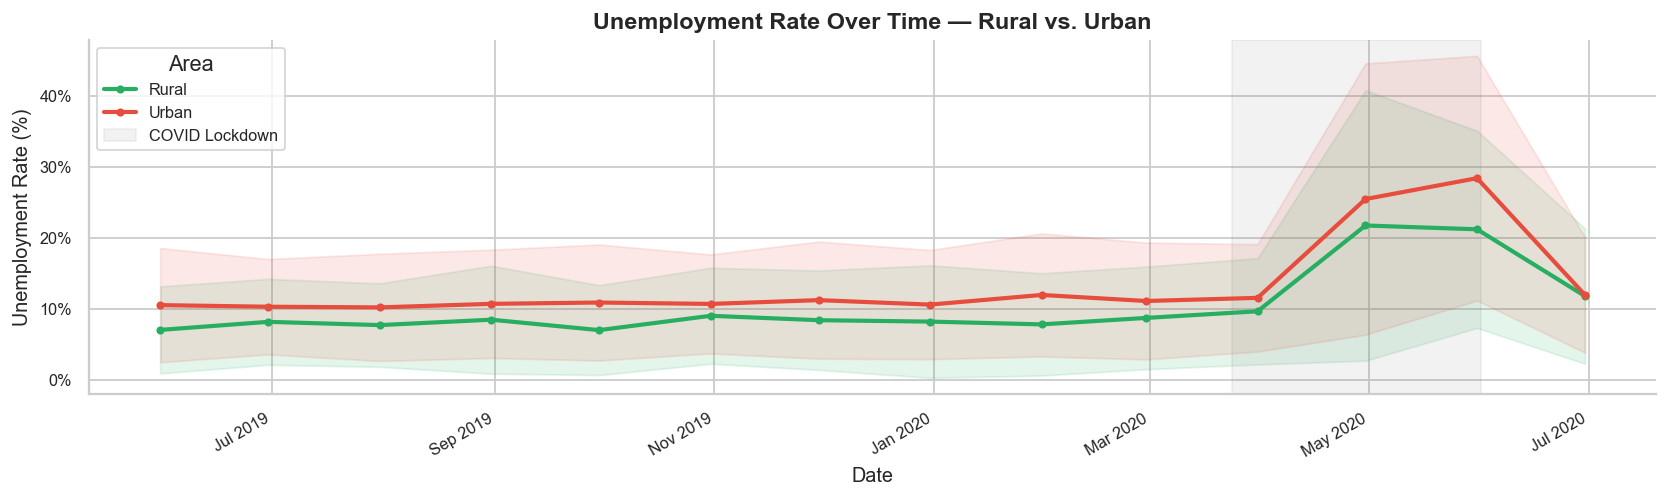

In [7]:
area_ts = (
    df.dropna(subset=['Area'])
      .groupby(['Date','Area'])['Unemployment_Rate']
      .agg(['mean','std'])
      .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 4))
colors_area = {'Rural': '#27AE60', 'Urban': '#E74C3C'}

for area, grp in area_ts.groupby('Area'):
    col = colors_area[area]
    ax.fill_between(grp['Date'], grp['mean'] - grp['std'], grp['mean'] + grp['std'],
                    alpha=0.12, color=col)
    ax.plot(grp['Date'], grp['mean'], color=col, linewidth=2.3,
            marker='o', markersize=3.5, label=area)

ax.axvspan(pd.Timestamp('2020-03-24'), pd.Timestamp('2020-06-01'),
           alpha=0.1, color='grey', label='COVID Lockdown')
ax.set_title('Unemployment Rate Over Time — Rural vs. Urban', fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
ax.legend(title='Area')
plt.tight_layout()
plt.show()

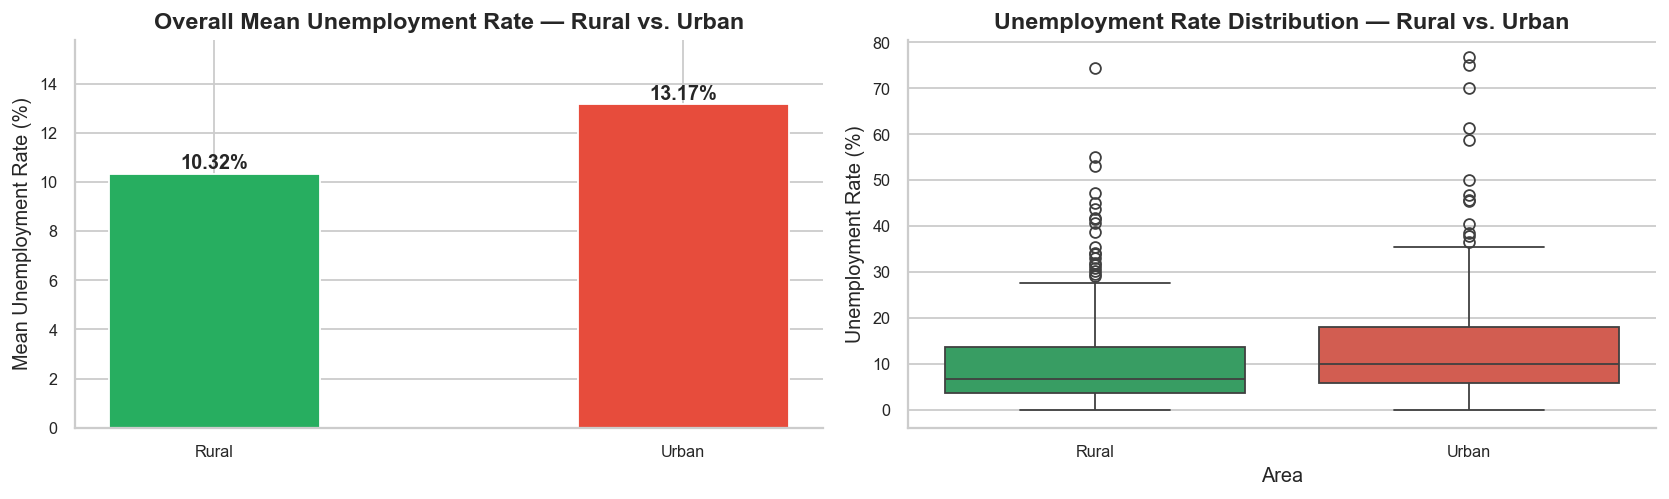

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

area_overall = df.dropna(subset=['Area']).groupby('Area')['Unemployment_Rate'].mean()
bars = axes[0].bar(area_overall.index, area_overall.values,
                   color=[colors_area[a] for a in area_overall.index],
                   edgecolor='white', width=0.45)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.2f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Overall Mean Unemployment Rate — Rural vs. Urban', fontweight='bold')
axes[0].set_ylabel('Mean Unemployment Rate (%)')
axes[0].set_ylim(0, area_overall.max() * 1.2)

sns.boxplot(x='Area', y='Unemployment_Rate', data=df.dropna(subset=['Area']),
            palette=colors_area, order=['Rural','Urban'], ax=axes[1])
axes[1].set_title('Unemployment Rate Distribution — Rural vs. Urban', fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()